# Step 1: Enhanced Image Preprocessing and Data Augmentation


In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()

PROJECT_ROOT = None
for candidate in [current_path] + list(current_path.parents):
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot find project root. Please run this notebook inside the 760-Group1 project folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Src exists:", (PROJECT_ROOT / "src").exists())

Project root: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1
Src exists: True


In [2]:
import torch
import torch.nn as nn
from torchvision import models

from src.config import (
    DEVICE,
    NUM_CLASSES,
    CLASS_NAMES,
)

device = torch.device(DEVICE)

print("Device:", device)
print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

Device: cpu
Number of classes: 5
Class names: ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image, ImageFilter

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import cv2

from src.config import (
    DATA_DIR,
    SPLIT_CSV,
    FIGURE_DIR,
    RESULT_DIR,
    CLASS_NAMES,
    BATCH_SIZE,
    RANDOM_SEED,
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR)
print("Split CSV:", SPLIT_CSV)
print("Figure directory:", FIGURE_DIR)

Data directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\data\raw\Digital Knee X-ray Images\MedicalExpert-I
Split CSV: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\data\processed\splits.csv
Figure directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures


## try 310*310 To retain more details

In [4]:
DENSENET_INPUT_SIZE = 310

print("DenseNet improved input size:", DENSENET_INPUT_SIZE)

DenseNet improved input size: 310


## Apply CLAHE to a PIL image.  

CLAHE improves local contrast and may help highlight  
subtle joint-space narrowing or small osteophyte features.  

In [5]:
def apply_clahe_pil(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    
    # Convert PIL image to grayscale numpy array
    image_gray = image.convert("L")
    image_np = np.array(image_gray)

    # Create CLAHE object
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    # Apply CLAHE
    enhanced_np = clahe.apply(image_np)

    # Convert back to PIL image
    enhanced_image = Image.fromarray(enhanced_np)

    return enhanced_image


def apply_sharpen_pil(image):
    """
    Apply image sharpening to a PIL image.
    This can enhance bone edges and texture.
    """

    sharpened_image = image.filter(ImageFilter.SHARPEN)

    return sharpened_image


def apply_clahe_and_sharpen(image):
    """
    Full enhancement pipeline:
    1. Convert to grayscale
    2. Apply CLAHE
    3. Apply sharpening
    4. Convert to RGB for pretrained DenseNet
    """

    image = apply_clahe_pil(image)
    image = apply_sharpen_pil(image)

    # Convert to RGB because pretrained DenseNet expects 3-channel input
    image = image.convert("RGB")

    return image

## read split CSV

In [6]:
if not SPLIT_CSV.exists():
    raise FileNotFoundError(
        f"Cannot find split file: {SPLIT_CSV}. Please run create_split.py first."
    )

split_df = pd.read_csv(SPLIT_CSV)

print("Split CSV shape:", split_df.shape)
display(split_df.head())

print("\nSplit counts:")
display(split_df["split"].value_counts())

print("\nClass distribution by split:")
display(split_df.groupby(["split", "label", "class_name"]).size())

Split CSV shape: (1464, 6)


,path,filename,folder,label,class_name,split
0,C:\Users\yuely\OneDrive\Desktop\cs760\760-Grou...,DoubtfulG1 (431).png,1Doubtful,1,Doubtful,train
1,C:\Users\yuely\OneDrive\Desktop\cs760\760-Grou...,SevereG4 (164).png,4Severe,4,Severe,train
2,C:\Users\yuely\OneDrive\Desktop\cs760\760-Grou...,DoubtfulG1 (104).png,1Doubtful,1,Doubtful,train
3,C:\Users\yuely\OneDrive\Desktop\cs760\760-Grou...,MildG2 (96).png,2Mild,2,Mild,train
4,C:\Users\yuely\OneDrive\Desktop\cs760\760-Grou...,SevereG4 (127).png,4Severe,4,Severe,train



Split counts:


split
train    1024
test      294
val       146
Name: count, dtype: int64


Class distribution by split:


split  label  class_name
test   0      Normal         91
       1      Doubtful       88
       2      Mild           38
       3      Moderate       35
       4      Severe         42
train  0      Normal        316
       1      Doubtful      308
       2      Mild          134
       3      Moderate      122
       4      Severe        144
val    0      Normal         45
       1      Doubtful       44
       2      Mild           19
       3      Moderate       18
       4      Severe         20
dtype: int64

## Processing image paths

In [7]:
def get_image_path_from_row(row):
    """
    Support different split CSV formats.

    Expected possibilities:
    1. path column
    2. relative_path column
    3. folder + filename
    4. label + class_name + filename
    """

    if "path" in row and pd.notna(row["path"]):
        path = Path(str(row["path"]))

        if path.exists():
            return path

        # Rebuild path if absolute path is from another machine
        parts = list(path.parts)

        if "MedicalExpert-I" in parts:
            index = parts.index("MedicalExpert-I")
            relative_part = Path(*parts[index + 1:])
            candidate = DATA_DIR / relative_part

            if candidate.exists():
                return candidate

    if "relative_path" in row and pd.notna(row["relative_path"]):
        candidate = DATA_DIR / str(row["relative_path"])

        if candidate.exists():
            return candidate

    if "folder" in row and "filename" in row:
        candidate = DATA_DIR / str(row["folder"]) / str(row["filename"])

        if candidate.exists():
            return candidate

    if "filename" in row and "label" in row and "class_name" in row:
        folder = f"{int(row['label'])}{row['class_name']}"
        candidate = DATA_DIR / folder / str(row["filename"])

        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Cannot find image path for row:\n{row}")

## Visualize the effects of CLAHE + Sharpen

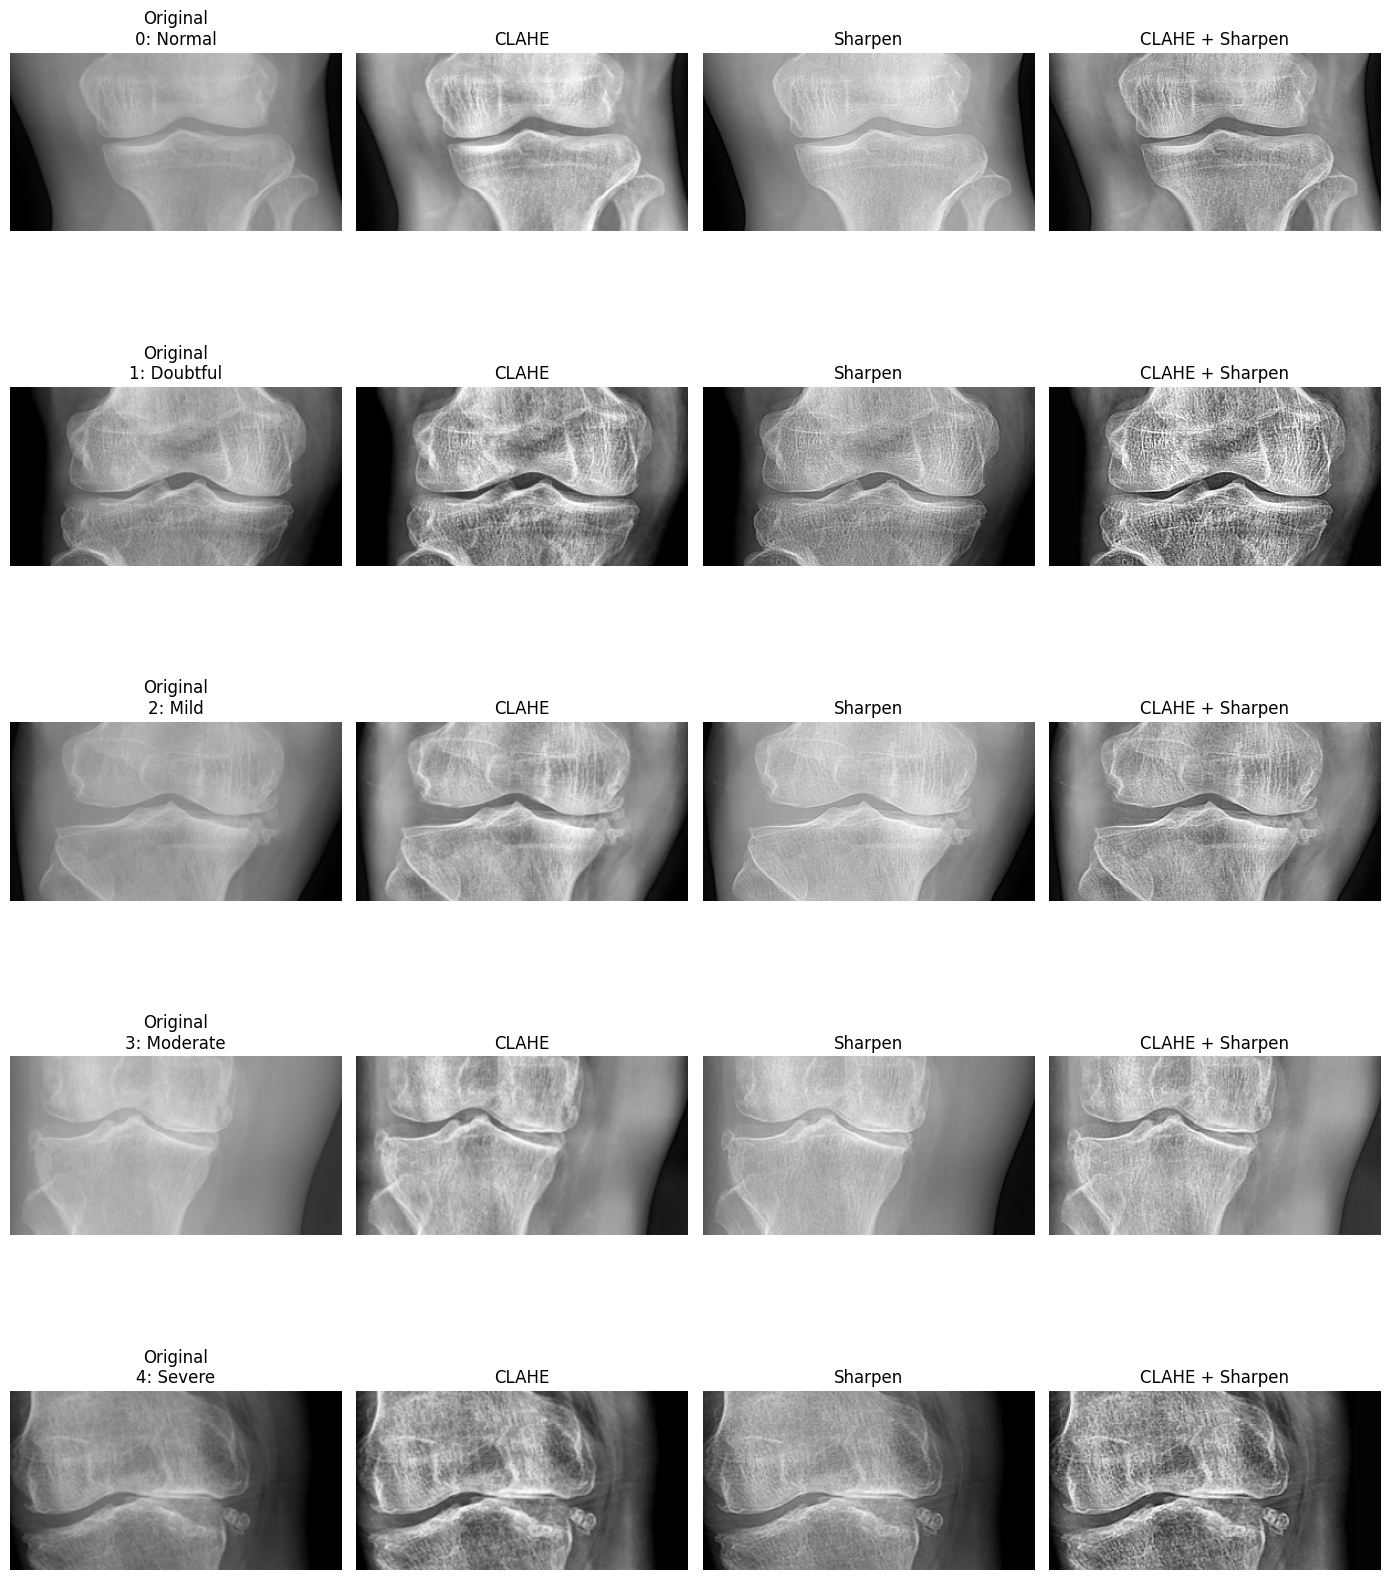

Saved figure to: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\densenet_step1_clahe_sharpen_examples.png


In [8]:
def show_enhancement_examples(df, samples_per_class=1):
    selected_rows = []

    for label in sorted(df["label"].unique()):
        class_df = df[df["label"] == label]
        selected_rows.append(class_df.head(samples_per_class))

    selected_df = pd.concat(selected_rows, ignore_index=True)

    num_rows = len(selected_df)

    fig, axes = plt.subplots(
        num_rows,
        4,
        figsize=(14, 3.5 * num_rows)
    )

    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(selected_df.iterrows()):
        image_path = get_image_path_from_row(row)

        original = Image.open(image_path).convert("RGB")
        gray = original.convert("L")
        clahe_img = apply_clahe_pil(original)
        sharpen_img = apply_sharpen_pil(gray)
        clahe_sharpen_img = apply_clahe_and_sharpen(original)

        label = int(row["label"])
        class_name = CLASS_NAMES[label]

        axes[i, 0].imshow(original, cmap="gray")
        axes[i, 0].set_title(f"Original\n{label}: {class_name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(clahe_img, cmap="gray")
        axes[i, 1].set_title("CLAHE")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(sharpen_img, cmap="gray")
        axes[i, 2].set_title("Sharpen")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(clahe_sharpen_img, cmap="gray")
        axes[i, 3].set_title("CLAHE + Sharpen")
        axes[i, 3].axis("off")

    plt.tight_layout()

    output_path = FIGURE_DIR / "densenet_step1_clahe_sharpen_examples.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure to:", output_path)


train_df = split_df[split_df["split"] == "train"].copy()
show_enhancement_examples(train_df, samples_per_class=1)

## enhanced transforms
we put CLAHE + Sharpen into the transform. 

In [9]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]


train_enhanced_transform = transforms.Compose([
    transforms.Lambda(apply_clahe_and_sharpen),
    transforms.Resize((DENSENET_INPUT_SIZE, DENSENET_INPUT_SIZE)),

    # Random augmentation only for training
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    ),
])


eval_enhanced_transform = transforms.Compose([
    transforms.Lambda(apply_clahe_and_sharpen),
    transforms.Resize((DENSENET_INPUT_SIZE, DENSENET_INPUT_SIZE)),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    ),
])

notebook Dataset

In [10]:
class DenseNetEnhancedDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = get_image_path_from_row(row)
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

enhanced DataLoader

In [11]:
train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "val"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

train_enhanced_dataset = DenseNetEnhancedDataset(
    dataframe=train_df,
    transform=train_enhanced_transform
)

val_enhanced_dataset = DenseNetEnhancedDataset(
    dataframe=val_df,
    transform=eval_enhanced_transform
)

test_enhanced_dataset = DenseNetEnhancedDataset(
    dataframe=test_df,
    transform=eval_enhanced_transform
)

train_enhanced_loader = DataLoader(
    train_enhanced_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_enhanced_loader = DataLoader(
    val_enhanced_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_enhanced_loader = DataLoader(
    test_enhanced_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Enhanced train batches:", len(train_enhanced_loader))
print("Enhanced validation batches:", len(val_enhanced_loader))
print("Enhanced test batches:", len(test_enhanced_loader))

images, labels = next(iter(train_enhanced_loader))

print("Enhanced image batch shape:", images.shape)
print("Enhanced label batch shape:", labels.shape)
print("Labels:", labels[:10])

Enhanced train batches: 64
Enhanced validation batches: 10
Enhanced test batches: 19
Enhanced image batch shape: torch.Size([16, 3, 310, 310])
Enhanced label batch shape: torch.Size([16])
Labels: tensor([0, 0, 2, 1, 0, 1, 4, 2, 4, 4])


Display the enhanced batch image

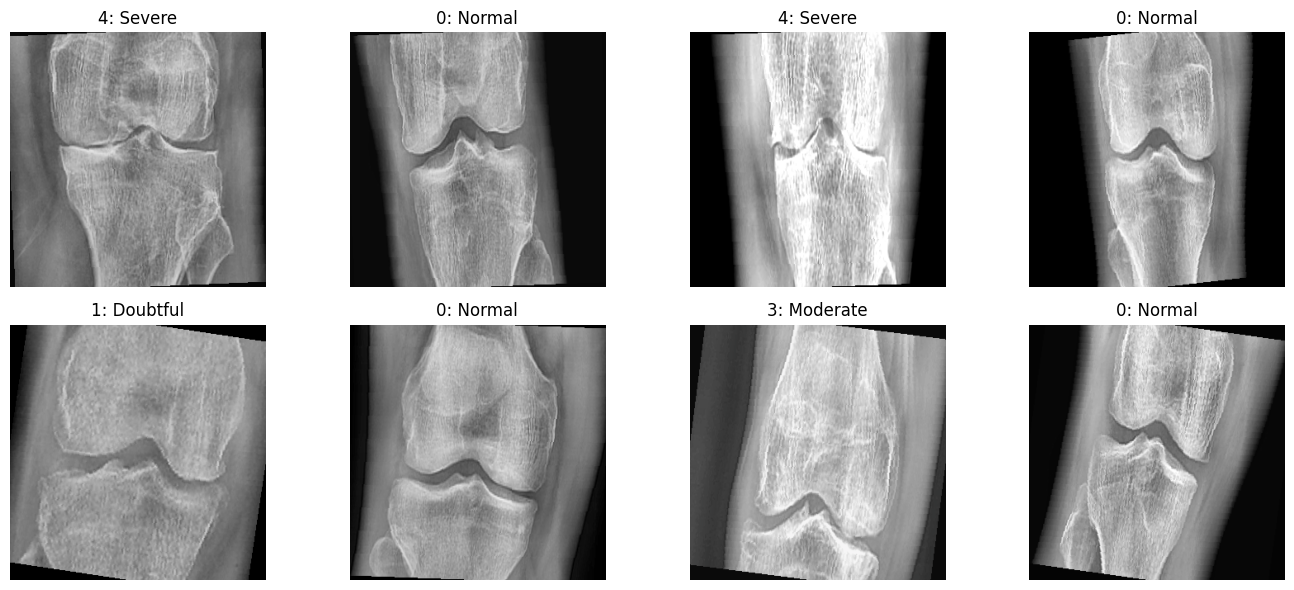

Saved enhanced batch figure to: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\densenet_step1_enhanced_train_batch.png


In [12]:
def denormalize_image(tensor, mean=imagenet_mean, std=imagenet_std):
    image = tensor.clone().detach().cpu()

    for channel, m, s in zip(image, mean, std):
        channel.mul_(s).add_(m)

    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


def show_enhanced_batch(data_loader, num_images=8):
    images, labels = next(iter(data_loader))

    num_images = min(num_images, len(images))

    plt.figure(figsize=(14, 6))

    for i in range(num_images):
        image_np = denormalize_image(images[i])
        label = int(labels[i])
        class_name = CLASS_NAMES[label]

        plt.subplot(2, 4, i + 1)
        plt.imshow(image_np)
        plt.title(f"{label}: {class_name}")
        plt.axis("off")

    plt.tight_layout()

    output_path = FIGURE_DIR / "densenet_step1_enhanced_train_batch.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved enhanced batch figure to:", output_path)


show_enhanced_batch(train_enhanced_loader, num_images=8)

# Step 2: Modify DenseNet121 Classification Head

In [13]:
import torch
import torch.nn as nn
from torchvision import models

from src.config import NUM_CLASSES, CLASS_NAMES

## improved DenseNet121 model
Improvements:
    1. Use pretrained DenseNet121 backbone.
    2. Replace the original classifier with a stronger classifier head.
    3. Freeze feature extractor first.
    4. Train classifier head first.

In [14]:
def get_densenet121_improved(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
    hidden_features=512,
):

    try:
        from torchvision.models import DenseNet121_Weights

        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)

    except Exception:
        model = models.densenet121(pretrained=pretrained)

    # Freeze all pretrained layers first
    for param in model.parameters():
        param.requires_grad = False

    # Get input features of original DenseNet classifier
    in_features = model.classifier.in_features

    # Replace original classifier with improved classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, hidden_features),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout),
        nn.Linear(hidden_features, num_classes),
    )

    # Make classifier head trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

## Define the fine-tuning stage control function
Control which parts of DenseNet121 are trainable.  
stage="head":  
    Train classifier head only.  
stage="last_block":  
    Train classifier head + denseblock4 + norm5.  
stage="last_two_blocks":  
    Train classifier head + denseblock3 + transition3 + denseblock4 + norm5.

In [15]:
def set_densenet_trainable_stage(model, stage="head"):
    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Always train classifier head
    for param in model.classifier.parameters():
        param.requires_grad = True

    if stage in ["last_block", "last_two_blocks"]:
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True

        for param in model.features.norm5.parameters():
            param.requires_grad = True

    if stage == "last_two_blocks":
        for param in model.features.denseblock3.parameters():
            param.requires_grad = True

        for param in model.features.transition3.parameters():
            param.requires_grad = True

    return model

Count trainable and total parameters.

In [16]:
def count_trainable_parameters(model):

    trainable_params = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

    total_params = sum(
        p.numel() for p in model.parameters()
    )

    return trainable_params, total_params

## create improved DenseNet121 check Classification Head

In [17]:
improved_densenet = get_densenet121_improved(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
    hidden_features=512,
)

improved_densenet = set_densenet_trainable_stage(
    improved_densenet,
    stage="head"
)

improved_densenet = improved_densenet.to(device)

trainable_params, total_params = count_trainable_parameters(improved_densenet)

print("Improved DenseNet121 classifier:")
print(improved_densenet.classifier)

print("\nTrainable parameters:")
print(f"{trainable_params:,} / {total_params:,}")

print("\nOutput classes:")
for index, class_name in enumerate(CLASS_NAMES):
    print(index, class_name)

Improved DenseNet121 classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=512, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=5, bias=True)
)

Trainable parameters:
527,365 / 7,481,221

Output classes:
0 Normal
1 Doubtful
2 Mild
3 Moderate
4 Severe


check forward pass  
Step 1 enhanced images。

In [18]:
images, labels = next(iter(train_enhanced_loader))

images = images.to(device)

with torch.no_grad():
    outputs = improved_densenet(images)

print("Input image shape:", images.shape)
print("Output shape:", outputs.shape)
print("Label shape:", labels.shape)

Input image shape: torch.Size([16, 3, 310, 310])
Output shape: torch.Size([16, 5])
Label shape: torch.Size([16])


# Step 3: Flexible Loss Setup
we create a flexible loss function setup for DenseNet121 training.  

We support three loss functions:  
1. Standard CrossEntropyLoss  
2. Class-weighted CrossEntropyLoss  
3. Ordinal-aware weighted loss  

The purpose is to compare whether different loss functions improve DenseNet121 performance.  

This is important because the dataset is imbalanced and KL grades are ordinal:  

0 Normal < 1 Doubtful < 2 Mild < 3 Moderate < 4 Severe  

Class-weighted loss addresses class imbalance, while ordinal-aware loss penalizes distant-grade errors more strongly.  

## Calculate class weights using only the training set.

Formula:weight_i = total_train_samples / (num_classes * class_count_i)  
This gives larger weights to minority classes.

In [19]:
def calculate_class_weights_from_split(split_df, device):

    train_df = split_df[split_df["split"] == "train"].copy()

    class_counts = (
        train_df["label"]
        .value_counts()
        .sort_index()
        .reindex(range(NUM_CLASSES), fill_value=0)
    )

    if (class_counts == 0).any():
        raise ValueError("Some classes have zero samples in the training set.")

    total_samples = len(train_df)

    class_weights = total_samples / (NUM_CLASSES * class_counts.values)

    class_weights_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32
    ).to(device)

    weight_df = pd.DataFrame({
        "label": list(range(NUM_CLASSES)),
        "class_name": CLASS_NAMES,
        "train_count": class_counts.values,
        "class_weight": class_weights,
    })

    return class_weights_tensor, weight_df


class_weights, class_weight_df = calculate_class_weights_from_split(
    split_df=split_df,
    device=device
)

display(class_weight_df)
print("Class weights tensor:", class_weights)

,label,class_name,train_count,class_weight
0,0,Normal,316,0.648101
1,1,Doubtful,308,0.664935
2,2,Mild,134,1.528358
3,3,Moderate,122,1.678689
4,4,Severe,144,1.422222


Class weights tensor: tensor([0.6481, 0.6649, 1.5284, 1.6787, 1.4222])


## Ordinal-aware Weighted Loss
This combines:  
    1. Cross-entropy loss  
    2. Optional class weights  
    3. Ordinal distance penalty  

The ordinal penalty is based on how far the predicted probability distribution is from the true KL grade.

In [20]:
class OrdinalAwareWeightedLoss(nn.Module):


    def __init__(self, num_classes, class_weights=None, alpha=1.0):
        super().__init__()

        self.num_classes = num_classes
        self.class_weights = class_weights
        self.alpha = alpha

    def forward(self, logits, targets):
        """
        Args:
            logits: model outputs, shape [batch_size, num_classes]
            targets: true labels, shape [batch_size]

        Returns:
            scalar loss
        """

        # Standard cross-entropy loss for each sample
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights,
            reduction="none"
        )

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # Class indices: [0, 1, 2, 3, 4]
        class_indices = torch.arange(
            self.num_classes,
            device=logits.device
        ).float().unsqueeze(0)

        # True labels: shape [batch_size, 1]
        targets_float = targets.float().unsqueeze(1)

        # Distance between every predicted class and true class
        distances = torch.abs(class_indices - targets_float)

        # Normalize distance to range [0, 1]
        distances = distances / (self.num_classes - 1)

        # Expected distance under predicted probability distribution
        expected_distance = torch.sum(probs * distances, dim=1)

        # Increase loss if probability is assigned to far-away classes
        loss = ce_loss * (1.0 + self.alpha * expected_distance)

        return loss.mean()

## flexible loss builder
Build loss function based on loss_type.   

Options:   
standard  
classweighted  
ordinary  

In [21]:
def build_loss_function(loss_type, class_weights=None, ordinal_alpha=1.0):
    if loss_type == "standard":
        criterion = nn.CrossEntropyLoss()

    elif loss_type == "classweighted":
        criterion = nn.CrossEntropyLoss(
            weight=class_weights
        )

    elif loss_type == "ordinal":
        criterion = OrdinalAwareWeightedLoss(
            num_classes=NUM_CLASSES,
            class_weights=class_weights,
            alpha=ordinal_alpha
        )

    else:
        raise ValueError(
            "Unknown loss_type. Choose from: standard, classweighted, ordinal"
        )

    return criterion

## choose loss type

In [22]:
LOSS_TYPE = "classweighted"   #  "standard", "classweighted", "ordinal"
ORDINAL_ALPHA = 1.0

criterion = build_loss_function(
    loss_type=LOSS_TYPE,
    class_weights=class_weights,
    ordinal_alpha=ORDINAL_ALPHA
)

print("Selected loss type:", LOSS_TYPE)
print("Ordinal alpha:", ORDINAL_ALPHA)
print("Criterion:", criterion)

Selected loss type: ordinal
Ordinal alpha: 1.0
Criterion: OrdinalAwareWeightedLoss()


Test whether the loss can be calculated correctly.

In [23]:
images, labels = next(iter(train_enhanced_loader))

images = images.to(device)
labels = labels.to(device)

improved_densenet.eval()

with torch.no_grad():
    outputs = improved_densenet(images)
    test_loss = criterion(outputs, labels)

print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Test loss:", test_loss.item())

Output shape: torch.Size([16, 5])
Labels shape: torch.Size([16])
Test loss: 2.3202736377716064


# Step 4: Two-stage Fine-tuning

we train the improved DenseNet121 model using two-stage fine-tuning.  

Stage 1:  
- Freeze the DenseNet121 feature extractor.  
- Train only the new classifier head.  
- Use a slightly larger learning rate.  

Stage 2:  
- Unfreeze the final DenseNet block.  
- Fine-tune denseblock4, norm5, and the classifier head.  
- Use a smaller learning rate.  
- Apply learning-rate scheduler and early stopping.  

This helps the model adapt to the knee X-ray classification task while reducing the risk of overfitting.  

Parameter settings

In [24]:
OUTPUT_PREFIX = f"densenet121_improved_{LOSS_TYPE}"

STAGE_1_EPOCHS = 3
STAGE_2_MAX_EPOCHS = 20

STAGE_1_LR = 0.0005
STAGE_2_LR = 0.0001

EARLY_STOPPING_PATIENCE = 5

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

print("Output prefix:", OUTPUT_PREFIX)
print("Loss type:", LOSS_TYPE)
print("Stage 1 epochs:", STAGE_1_EPOCHS)
print("Stage 2 max epochs:", STAGE_2_MAX_EPOCHS)
print("Stage 1 learning rate:", STAGE_1_LR)
print("Stage 2 learning rate:", STAGE_2_LR)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Scheduler factor:", SCHEDULER_FACTOR)
print("Scheduler patience:", SCHEDULER_PATIENCE)

Output prefix: densenet121_improved_ordinal
Loss type: ordinal
Stage 1 epochs: 3
Stage 2 max epochs: 20
Stage 1 learning rate: 0.0005
Stage 2 learning rate: 0.0001
Early stopping patience: 5
Scheduler factor: 0.5
Scheduler patience: 2


## train / validation

In [25]:
from tqdm.notebook import tqdm

def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch_desc="Training"):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=epoch_desc,
        leave=False
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        current_loss = running_loss / total
        current_acc = correct / total

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate_one_epoch(model, data_loader, criterion, device, epoch_desc="Validation"):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        data_loader,
        desc=epoch_desc,
        leave=False
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            current_loss = running_loss / total
            current_acc = correct / total

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

## Stage 1 — only train classifier head

In [ ]:
import copy
from tqdm.notebook import tqdm

# Re-create model to make sure training starts cleanly
improved_densenet = get_densenet121_improved(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
    hidden_features=512,
)

improved_densenet = set_densenet_trainable_stage(
    improved_densenet,
    stage="head"
)

improved_densenet = improved_densenet.to(device)

trainable_params, total_params = count_trainable_parameters(improved_densenet)

print("=" * 60)
print("Stage 1: Train classifier head only")
print("=" * 60)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

stage_1_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, improved_densenet.parameters()),
    lr=STAGE_1_LR
)

history = []

best_val_loss = float("inf")
best_val_acc = 0.0
best_model_state = None

global_epoch = 0

for epoch in range(1, STAGE_1_EPOCHS + 1):
    global_epoch += 1

    train_loss, train_acc = train_one_epoch(
        model=improved_densenet,
        train_loader=train_enhanced_loader,
        criterion=criterion,
        optimizer=stage_1_optimizer,
        device=device,
        epoch_desc=f"Stage 1 Epoch {epoch}/{STAGE_1_EPOCHS} Train"
    )

    val_loss, val_acc = evaluate_one_epoch(
        model=improved_densenet,
        data_loader=val_enhanced_loader,
        criterion=criterion,
        device=device,
        epoch_desc=f"Stage 1 Epoch {epoch}/{STAGE_1_EPOCHS} Val"
    )

    history.append({
        "stage": "head_only",
        "epoch_stage": epoch,
        "epoch_global": global_epoch,
        "learning_rate": get_current_lr(stage_1_optimizer),
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"[Stage 1 | Epoch {epoch}/{STAGE_1_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(improved_densenet.state_dict())
        print("Saved best model state from Stage 1.")

Stage 1: Train classifier head only
Trainable parameters: 527,365 / 7,481,221


Stage 1 Epoch 1/3 Train:   0%|          | 0/64 [00:00<?, ?it/s]

## Stage 2 — unfreesze denseblock4 + norm5 + classifier

In [ ]:
# Stage 2: Fine-tune denseblock4 + norm5 + classifier

improved_densenet = set_densenet_trainable_stage(
    improved_densenet,
    stage="last_block"
)

trainable_params, total_params = count_trainable_parameters(improved_densenet)

print("=" * 60)
print("Stage 2: Fine-tune denseblock4 + norm5 + classifier")
print("=" * 60)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

stage_2_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, improved_densenet.parameters()),
    lr=STAGE_2_LR
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    stage_2_optimizer,
    mode="min",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE
)

epochs_without_improvement = 0

for epoch in range(1, STAGE_2_MAX_EPOCHS + 1):
    global_epoch += 1

    train_loss, train_acc = train_one_epoch(
        model=improved_densenet,
        train_loader=train_enhanced_loader,
        criterion=criterion,
        optimizer=stage_2_optimizer,
        device=device,
        epoch_desc=f"Stage 2 Epoch {epoch}/{STAGE_2_MAX_EPOCHS} Train"
    )

    val_loss, val_acc = evaluate_one_epoch(
        model=improved_densenet,
        data_loader=val_enhanced_loader,
        criterion=criterion,
        device=device,
        epoch_desc=f"Stage 2 Epoch {epoch}/{STAGE_2_MAX_EPOCHS} Val"
    )

    scheduler.step(val_loss)

    current_lr = get_current_lr(stage_2_optimizer)

    history.append({
        "stage": "last_block",
        "epoch_stage": epoch,
        "epoch_global": global_epoch,
        "learning_rate": current_lr,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"[Stage 2 | Epoch {epoch}/{STAGE_2_MAX_EPOCHS}] "
        f"LR: {current_lr:.8f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(improved_densenet.state_dict())
        epochs_without_improvement = 0
        print("New best validation loss. Saved model state.")
    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE} epochs"
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

## Load the best model and save

In [ ]:
from pathlib import Path
import sys

# Find project root
current_path = Path.cwd().resolve()

PROJECT_ROOT = None
for candidate in [current_path] + list(current_path.parents):
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot find project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODEL_DIR, RESULT_DIR, FIGURE_DIR

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_DIR:", MODEL_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

In [ ]:
OUTPUT_PREFIX = f"densenet121_improved_{LOSS_TYPE}"

print("OUTPUT_PREFIX:", OUTPUT_PREFIX)

In [ ]:
if best_model_state is not None:
    improved_densenet.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")
else:
    print("Warning: No best model state found.")

best_model_path = MODEL_DIR / f"{OUTPUT_PREFIX}_best.pth"

torch.save(
    improved_densenet.state_dict(),
    best_model_path
)

print("Best model saved to:", best_model_path)
print("Best validation loss:", best_val_loss)
print("Best validation accuracy:", best_val_acc)

save training history and summary

In [ ]:
history_df = pd.DataFrame(history)

history_path = RESULT_DIR / f"{OUTPUT_PREFIX}_training_history.csv"
history_df.to_csv(history_path, index=False)

summary = {
    "model": OUTPUT_PREFIX,
    "backbone": "DenseNet121",
    "loss_type": LOSS_TYPE,
    "ordinal_alpha": ORDINAL_ALPHA if LOSS_TYPE == "ordinal" else None,
    "stage_1_epochs": STAGE_1_EPOCHS,
    "stage_2_max_epochs": STAGE_2_MAX_EPOCHS,
    "stage_1_learning_rate": STAGE_1_LR,
    "stage_2_learning_rate": STAGE_2_LR,
    "optimizer": "Adam",
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": SCHEDULER_FACTOR,
    "scheduler_patience": SCHEDULER_PATIENCE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "best_val_loss": best_val_loss,
    "best_val_acc": best_val_acc,
    "epochs_trained": len(history_df),
}

summary_df = pd.DataFrame([summary])

summary_path = RESULT_DIR / f"{OUTPUT_PREFIX}_training_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)
display(history_df.tail())

print("Training history saved to:", history_path)
print("Training summary saved to:", summary_path)

Draw training curves

In [ ]:
loss_curve_path = FIGURE_DIR / f"{OUTPUT_PREFIX}_loss_curve.png"
accuracy_curve_path = FIGURE_DIR / f"{OUTPUT_PREFIX}_accuracy_curve.png"

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch_global"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch_global"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{OUTPUT_PREFIX} Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(loss_curve_path, dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch_global"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch_global"], history_df["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{OUTPUT_PREFIX} Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(accuracy_curve_path, dpi=300)
plt.show()

print("Loss curve saved to:", loss_curve_path)
print("Accuracy curve saved to:", accuracy_curve_path)

## Step 5: Evaluate improved DenseNet121 on test set

In [ ]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()

PROJECT_ROOT = None
for candidate in [current_path] + list(current_path.parents):
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot find project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from src.config import (
    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    CLASS_NAMES,
    DEVICE,
)

from src.metrics import calculate_classification_metrics

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(DEVICE)

OUTPUT_PREFIX = f"densenet121_improved_{LOSS_TYPE}"

print("Device:", device)
print("OUTPUT_PREFIX:", OUTPUT_PREFIX)
print("MODEL_DIR:", MODEL_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

## best model

In [ ]:
best_model_path = MODEL_DIR / f"{OUTPUT_PREFIX}_best.pth"

print("Best model path:", best_model_path)
print("Model exists:", best_model_path.exists())

if not best_model_path.exists():
    raise FileNotFoundError(
        f"Cannot find best model: {best_model_path}. "
        "Please finish Step 4 training and save the model first."
    )

# Load best model weights
improved_densenet.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

improved_densenet = improved_densenet.to(device)
improved_densenet.eval()

print("Best improved DenseNet121 model loaded successfully.")

## prediction

In [ ]:
def predict_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        progress_bar = tqdm(
            data_loader,
            desc="Evaluating on test set",
            leave=False
        )

        for images, labels in progress_bar:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return all_labels, all_preds, all_probs

## test set

In [ ]:
y_true, y_pred, y_probs = predict_model(
    model=improved_densenet,
    data_loader=test_enhanced_loader,
    device=device
)

overall_metrics, per_class_metrics, cm = calculate_classification_metrics(
    y_true=y_true,
    y_pred=y_pred,
    class_names=CLASS_NAMES
)

overall_df = pd.DataFrame([{
    "model": OUTPUT_PREFIX,
    "loss": LOSS_TYPE,
    **overall_metrics
}])

per_class_df = pd.DataFrame(per_class_metrics)

print("Overall Test Metrics")
display(overall_df)

print("Per-Class Metrics")
display(per_class_df)

save overall metrics and per-class metrics

In [ ]:
overall_metrics_path = RESULT_DIR / f"{OUTPUT_PREFIX}_test_metrics.csv"
per_class_metrics_path = RESULT_DIR / f"{OUTPUT_PREFIX}_per_class_metrics.csv"

overall_df.to_csv(overall_metrics_path, index=False)
per_class_df.to_csv(per_class_metrics_path, index=False)

print("Saved overall metrics to:", overall_metrics_path)
print("Saved per-class metrics to:", per_class_metrics_path)

save test predictions

In [ ]:
prediction_rows = []

for index, (true_label, pred_label, probs) in enumerate(zip(y_true, y_pred, y_probs)):
    row = {
        "sample_index": index,
        "true_label": true_label,
        "true_class": CLASS_NAMES[true_label],
        "pred_label": pred_label,
        "pred_class": CLASS_NAMES[pred_label],
        "correct": true_label == pred_label,
        "error_distance": abs(pred_label - true_label),
    }

    for class_index, prob in enumerate(probs):
        row[f"prob_{class_index}_{CLASS_NAMES[class_index]}"] = prob

    prediction_rows.append(row)

predictions_df = pd.DataFrame(prediction_rows)

predictions_path = RESULT_DIR / f"{OUTPUT_PREFIX}_test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

display(predictions_df.head(10))

print("Saved predictions to:", predictions_path)

Confusion matrix

In [ ]:
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{name}" for name in CLASS_NAMES],
    columns=[f"pred_{name}" for name in CLASS_NAMES]
)

display(cm_df)

cm_csv_path = RESULT_DIR / f"{OUTPUT_PREFIX}_confusion_matrix.csv"
cm_df.to_csv(cm_csv_path)

print("Saved confusion matrix CSV to:", cm_csv_path)

In [ ]:
def save_confusion_matrix(cm, class_names, output_path, title):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = range(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                horizontalalignment="center",
                verticalalignment="center"
            )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


cm_fig_path = FIGURE_DIR / f"{OUTPUT_PREFIX}_confusion_matrix.png"

save_confusion_matrix(
    cm=cm,
    class_names=CLASS_NAMES,
    output_path=cm_fig_path,
    title=f"Confusion Matrix: {OUTPUT_PREFIX}"
)

print("Saved confusion matrix figure to:", cm_fig_path)

Error distance analysis

In [ ]:
error_distance_counts = predictions_df["error_distance"].value_counts().sort_index()

display(error_distance_counts)

total_samples = len(predictions_df)
total_errors = (predictions_df["error_distance"] > 0).sum()
adjacent_errors = (predictions_df["error_distance"] == 1).sum()
distant_errors = (predictions_df["error_distance"] >= 2).sum()

error_summary = {
    "total_samples": total_samples,
    "total_errors": total_errors,
    "adjacent_errors": adjacent_errors,
    "distant_errors": distant_errors,
    "adjacent_error_rate_among_errors": adjacent_errors / total_errors if total_errors > 0 else 0,
    "distant_error_rate_among_errors": distant_errors / total_errors if total_errors > 0 else 0,
}

error_summary_df = pd.DataFrame([error_summary])

display(error_summary_df)

error_summary_path = RESULT_DIR / f"{OUTPUT_PREFIX}_error_distance_summary.csv"
error_summary_df.to_csv(error_summary_path, index=False)

print("Saved error distance summary to:", error_summary_path)

error distance

In [ ]:
error_distance_fig_path = FIGURE_DIR / f"{OUTPUT_PREFIX}_error_distance_distribution.png"

plt.figure(figsize=(7, 5))
plt.bar(error_distance_counts.index.astype(str), error_distance_counts.values)
plt.xlabel("Error Distance")
plt.ylabel("Number of Samples")
plt.title(f"Error Distance Distribution: {OUTPUT_PREFIX}")
plt.tight_layout()
plt.savefig(error_distance_fig_path, dpi=300)
plt.show()

print("Saved error distance figure to:", error_distance_fig_path)

## grad-cam

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

from src.config import (
    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    DEVICE,
    CLASS_NAMES,
)

device = torch.device(DEVICE)

OUTPUT_PREFIX = f"densenet121_improved_{LOSS_TYPE}"

gradcam_dir = FIGURE_DIR / "gradcam"
gradcam_dir.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Output prefix:", OUTPUT_PREFIX)
print("Grad-CAM output directory:", gradcam_dir)

In [ ]:
best_model_path = MODEL_DIR / f"{OUTPUT_PREFIX}_best.pth"

print("Best model path:", best_model_path)
print("Model exists:", best_model_path.exists())

if not best_model_path.exists():
    raise FileNotFoundError(
        f"Cannot find best model: {best_model_path}. "
        "Please finish training and save the best model first."
    )

improved_densenet.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

improved_densenet = improved_densenet.to(device)
improved_densenet.eval()

print("Best improved DenseNet121 model loaded for Grad-CAM.")

Grad-CAM class

In [ ]:
class GradCAM:
    """
    Grad-CAM implementation for CNN models.

    It stores:
    - forward activations from the target layer
    - backward gradients from the target layer
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = self.target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_hook = self.target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    def generate(self, input_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap for one image.

        Args:
            input_tensor: shape [1, 3, H, W]
            target_class: class index. If None, use predicted class.

        Returns:
            cam: normalized heatmap
            pred_class: predicted class index
            confidence: predicted probability
        """

        self.model.zero_grad()

        outputs = self.model(input_tensor)
        probs = torch.softmax(outputs, dim=1)

        pred_class = int(torch.argmax(probs, dim=1).item())
        confidence = float(probs[0, pred_class].item())

        if target_class is None:
            target_class = pred_class

        score = outputs[:, target_class]
        score.backward()

        weights = torch.mean(
            self.gradients,
            dim=(2, 3),
            keepdim=True
        )

        cam = torch.sum(weights * self.activations, dim=1)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(DENSENET_INPUT_SIZE, DENSENET_INPUT_SIZE),
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()

        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam, pred_class, confidence

Image loading and overlay functions

In [ ]:
def load_image_for_gradcam(row, transform, device):
    """
    Load one image from test_df and apply the same evaluation transform.
    """

    image_path = get_image_path_from_row(row)

    original_image = Image.open(image_path).convert("RGB")

    # For display: show enhanced image because this is what the model receives
    display_image = apply_clahe_and_sharpen(original_image)
    display_image = display_image.resize(
        (DENSENET_INPUT_SIZE, DENSENET_INPUT_SIZE)
    )

    input_tensor = transform(original_image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    return image_path, display_image, input_tensor


def create_gradcam_overlay(image, cam, alpha=0.45):
    """
    Overlay Grad-CAM heatmap on image.
    """

    image_np = np.array(image).astype(np.float32) / 255.0

    heatmap = plt.cm.jet(cam)
    heatmap = heatmap[:, :, :3]

    overlay = (1 - alpha) * image_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    return overlay

merge test_df and predictions

In [ ]:
# Make sure test_df exists
# If not, recreate it from split_df
if "test_df" not in globals():
    test_df = split_df[split_df["split"] == "test"].copy()

test_df_for_gradcam = test_df.reset_index(drop=True).copy()

# Make sure predictions_df exists
# If not, load it from saved CSV
predictions_path = RESULT_DIR / f"{OUTPUT_PREFIX}_test_predictions.csv"

if "predictions_df" not in globals():
    if predictions_path.exists():
        predictions_df = pd.read_csv(predictions_path)
    else:
        raise FileNotFoundError(
            f"Cannot find predictions file: {predictions_path}. "
            "Please run Step 5 evaluation first."
        )

gradcam_df = test_df_for_gradcam.copy()

gradcam_df["sample_index"] = predictions_df["sample_index"]
gradcam_df["pred_label"] = predictions_df["pred_label"]
gradcam_df["pred_class"] = predictions_df["pred_class"]
gradcam_df["correct"] = predictions_df["correct"]
gradcam_df["error_distance"] = predictions_df["error_distance"]

display(gradcam_df.head())

Grad-CAM sample

In [ ]:
def select_one_sample_per_class(df, prefer_correct=True):
    """
    Select one test sample for each true class.

    If prefer_correct=True, try to select correct predictions first.
    If no correct prediction exists for a class, select the first available sample.
    """

    selected_rows = []

    for label in sorted(df["label"].unique()):
        class_df = df[df["label"] == label]

        if prefer_correct:
            correct_df = class_df[class_df["correct"] == True]

            if len(correct_df) > 0:
                selected_rows.append(correct_df.iloc[[0]])
            else:
                selected_rows.append(class_df.iloc[[0]])
        else:
            selected_rows.append(class_df.iloc[[0]])

    selected_df = pd.concat(selected_rows, ignore_index=True)

    return selected_df


selected_gradcam_df = select_one_sample_per_class(
    gradcam_df,
    prefer_correct=True
)

display(selected_gradcam_df[[
    "sample_index",
    "label",
    "class_name",
    "pred_label",
    "pred_class",
    "correct",
    "error_distance"
]])

Grad-CAM results

In [ ]:
target_layer = improved_densenet.features.denseblock4

gradcam = GradCAM(
    model=improved_densenet,
    target_layer=target_layer
)

gradcam_results = []

for _, row in selected_gradcam_df.iterrows():
    image_path, display_image, input_tensor = load_image_for_gradcam(
        row=row,
        transform=eval_enhanced_transform,
        device=device
    )

    cam, pred_label, confidence = gradcam.generate(
        input_tensor=input_tensor,
        target_class=None
    )

    overlay = create_gradcam_overlay(
        image=display_image,
        cam=cam,
        alpha=0.45
    )

    true_label = int(row["label"])
    true_class = CLASS_NAMES[true_label]
    pred_class = CLASS_NAMES[pred_label]

    gradcam_results.append({
        "image_path": str(image_path),
        "display_image": display_image,
        "cam": cam,
        "overlay": overlay,
        "true_label": true_label,
        "true_class": true_class,
        "pred_label": pred_label,
        "pred_class": pred_class,
        "confidence": confidence,
        "correct": true_label == pred_label,
        "error_distance": abs(pred_label - true_label),
    })

gradcam.remove_hooks()

gradcam_results_df = pd.DataFrame([
    {
        "image_path": item["image_path"],
        "true_label": item["true_label"],
        "true_class": item["true_class"],
        "pred_label": item["pred_label"],
        "pred_class": item["pred_class"],
        "confidence": item["confidence"],
        "correct": item["correct"],
        "error_distance": item["error_distance"],
    }
    for item in gradcam_results
])

display(gradcam_results_df)

gradcam_results_path = RESULT_DIR / f"{OUTPUT_PREFIX}_gradcam_selected_samples.csv"
gradcam_results_df.to_csv(gradcam_results_path, index=False)

print("Saved Grad-CAM selected sample info to:", gradcam_results_path)

grad-cam picture

In [ ]:
def save_gradcam_grid(results, output_path, title):
    """
    Save Grad-CAM figure with original enhanced image and overlay.
    """

    num_rows = len(results)

    fig, axes = plt.subplots(
        num_rows,
        2,
        figsize=(8, 3.2 * num_rows)
    )

    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    fig.suptitle(title, fontsize=16)

    for i, item in enumerate(results):
        image = item["display_image"]
        overlay = item["overlay"]

        true_class = item["true_class"]
        pred_class = item["pred_class"]
        confidence = item["confidence"]
        correct = item["correct"]

        status = "Correct" if correct else "Wrong"

        axes[i, 0].imshow(image, cmap="gray")
        axes[i, 0].set_title(f"Input | True: {true_class}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(
            f"Grad-CAM | Pred: {pred_class} ({confidence:.2f}) | {status}"
        )
        axes[i, 1].axis("off")

    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved Grad-CAM figure to:", output_path)


gradcam_fig_path = gradcam_dir / f"{OUTPUT_PREFIX}_gradcam_examples.png"

save_gradcam_grid(
    results=gradcam_results,
    output_path=gradcam_fig_path,
    title=f"Grad-CAM Examples: {OUTPUT_PREFIX}"
)

# model comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import RESULT_DIR, FIGURE_DIR

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

model_metric_files = {
    "Baseline CNN + Standard CE": RESULT_DIR / "baseline_test_metrics.csv",
    "ResNet18 + Standard CE": RESULT_DIR / "resnet18_test_metrics.csv",
    "ResNet18 + Class-weighted CE": RESULT_DIR / "resnet18_classweighted_test_metrics.csv",
    "ResNet18 + Ordinal Loss": RESULT_DIR / "resnet18_ordinal_test_metrics.csv",

    "DenseNet121 + Standard CE": RESULT_DIR / "densenet121_test_metrics.csv",
    "DenseNet121 + Class-weighted CE": RESULT_DIR / "densenet121_classweighted_test_metrics.csv",
    "DenseNet121 + Ordinal Loss": RESULT_DIR / "densenet121_ordinal_test_metrics.csv",

    "Improved DenseNet121 + Ordinal Loss": RESULT_DIR / "densenet121_improved_ordinal_test_metrics.csv",

    "EfficientNet-B0 + Standard CE": RESULT_DIR / "efficientnet_b0_test_metrics.csv",
}

comparison_rows = []

for model_name, file_path in model_metric_files.items():
    if file_path.exists():
        df = pd.read_csv(file_path)
        row = df.iloc[0].to_dict()
        row["experiment"] = model_name
        comparison_rows.append(row)
        print("Loaded:", model_name)
    else:
        print("Missing:", model_name, "->", file_path)

comparison_df = pd.DataFrame(comparison_rows)

if comparison_df.empty:
    raise FileNotFoundError("No model metric files were found.")

display(comparison_df)

In [ ]:
columns_to_keep = [
    "experiment",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "mae",
    "qwk",
    "total_errors",
    "adjacent_errors",
    "distant_errors",
    "adjacent_error_rate_among_errors",
    "distant_error_rate_among_errors",
]

available_columns = [
    col for col in columns_to_keep if col in comparison_df.columns
]

final_comparison = comparison_df[available_columns].copy()

rename_map = {
    "experiment": "Experiment",
    "accuracy": "Accuracy",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
    "mae": "MAE",
    "qwk": "QWK",
    "total_errors": "Total Errors",
    "adjacent_errors": "Adjacent Errors",
    "distant_errors": "Distant Errors",
    "adjacent_error_rate_among_errors": "Adjacent Error Rate",
    "distant_error_rate_among_errors": "Distant Error Rate",
}

final_comparison = final_comparison.rename(columns=rename_map)

numeric_cols = final_comparison.columns.drop("Experiment")

final_comparison[numeric_cols] = final_comparison[numeric_cols].round(4)

display(final_comparison)

comparison_output_path = RESULT_DIR / "all_model_comparison_with_improved_densenet.csv"
final_comparison.to_csv(comparison_output_path, index=False)

print("Saved comparison table to:", comparison_output_path)

In [ ]:
print("Best model summary")
print("=" * 50)

if "Accuracy" in final_comparison.columns:
    best_acc = final_comparison.loc[final_comparison["Accuracy"].idxmax()]
    print("Best Accuracy:")
    print(best_acc[["Experiment", "Accuracy"]].to_string(index=False))

if "Macro F1" in final_comparison.columns:
    best_macro = final_comparison.loc[final_comparison["Macro F1"].idxmax()]
    print("\nBest Macro F1:")
    print(best_macro[["Experiment", "Macro F1"]].to_string(index=False))

if "MAE" in final_comparison.columns:
    best_mae = final_comparison.loc[final_comparison["MAE"].idxmin()]
    print("\nLowest MAE:")
    print(best_mae[["Experiment", "MAE"]].to_string(index=False))

if "QWK" in final_comparison.columns:
    best_qwk = final_comparison.loc[final_comparison["QWK"].idxmax()]
    print("\nBest QWK:")
    print(best_qwk[["Experiment", "QWK"]].to_string(index=False))

if "Distant Error Rate" in final_comparison.columns:
    best_distant = final_comparison.loc[final_comparison["Distant Error Rate"].idxmin()]
    print("\nLowest Distant Error Rate:")
    print(best_distant[["Experiment", "Distant Error Rate"]].to_string(index=False))

In [ ]:
metrics_to_plot = [
    "Accuracy",
    "Macro F1",
    "MAE",
    "QWK",
]

for metric in metrics_to_plot:
    if metric in final_comparison.columns:
        plot_df = final_comparison[["Experiment", metric]].copy()

        plt.figure(figsize=(10, 5))
        plt.bar(plot_df["Experiment"], plot_df[metric])
        plt.title(f"Model Comparison: {metric}")
        plt.xlabel("Model")
        plt.ylabel(metric)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        fig_path = FIGURE_DIR / f"model_comparison_{metric.lower().replace(' ', '_')}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved figure:", fig_path)

In [ ]:
ordinal_metrics = [
    "MAE",
    "QWK",
    "Distant Error Rate",
]

available_ordinal_metrics = [
    metric for metric in ordinal_metrics if metric in final_comparison.columns
]

ordinal_df = final_comparison[
    ["Experiment"] + available_ordinal_metrics
].copy()

display(ordinal_df)

ordinal_output_path = RESULT_DIR / "ordinal_sensitive_model_comparison.csv"
ordinal_df.to_csv(ordinal_output_path, index=False)

print("Saved ordinal-sensitive comparison to:", ordinal_output_path)